In [1]:
import pandas as pd

# Créer un jeu de commentaires fictifs (en français)
commentaires = [
    "Ce produit est génial, je le recommande vivement !",
    "Très mauvaise qualité, je suis déçu.",
    "J'adore, livraison rapide et produit parfait.",
    "Horrible expérience, je ne reviendrai plus jamais.",
    "Excellent service client, merci beaucoup !",
    "Produit cassé à l'arrivée, remboursement refusé.",
    "Super rapport qualité-prix, très satisfait.",
    "C'est nul, ça ne fonctionne pas du tout.",
    "Je suis ravi de mon achat, parfait !",
    "Arnaque totale, fuyez ce vendeur.",
    "Magnifique, exactement ce que je cherchais.",
    "Complètement raté, à éviter absolument.",
]

# 1 = positif, 0 = négatif
sentiments = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

# Créer le DataFrame
df = pd.DataFrame({
    "commentaire": commentaires,
    "sentiment": sentiments
})

print(df)


                                          commentaire  sentiment
0   Ce produit est génial, je le recommande viveme...          1
1                Très mauvaise qualité, je suis déçu.          0
2       J'adore, livraison rapide et produit parfait.          1
3   Horrible expérience, je ne reviendrai plus jam...          0
4          Excellent service client, merci beaucoup !          1
5    Produit cassé à l'arrivée, remboursement refusé.          0
6         Super rapport qualité-prix, très satisfait.          1
7            C'est nul, ça ne fonctionne pas du tout.          0
8                Je suis ravi de mon achat, parfait !          1
9                   Arnaque totale, fuyez ce vendeur.          0
10        Magnifique, exactement ce que je cherchais.          1
11            Complètement raté, à éviter absolument.          0


In [3]:
from sklearn.feature_extraction.text import CountVectorizer

# Créer le vectoriseur
vectoriseur = CountVectorizer()

# Transformer les commentaires en matrice de chiffres
X = vectoriseur.fit_transform(df["commentaire"])

# Afficher le résultat
print("Forme de la matrice :", X.shape)
print("\nLes mots du vocabulaire :")
print(vectoriseur.get_feature_names_out())

Forme de la matrice : (12, 59)

Les mots du vocabulaire :
['absolument' 'achat' 'adore' 'arnaque' 'arrivée' 'beaucoup' 'cassé' 'ce'
 'cherchais' 'client' 'complètement' 'de' 'du' 'déçu' 'est' 'et'
 'exactement' 'excellent' 'expérience' 'fonctionne' 'fuyez' 'génial'
 'horrible' 'jamais' 'je' 'le' 'livraison' 'magnifique' 'mauvaise' 'merci'
 'mon' 'ne' 'nul' 'parfait' 'pas' 'plus' 'prix' 'produit' 'qualité' 'que'
 'rapide' 'rapport' 'raté' 'ravi' 'recommande' 'refusé' 'remboursement'
 'reviendrai' 'satisfait' 'service' 'suis' 'super' 'totale' 'tout' 'très'
 'vendeur' 'vivement' 'ça' 'éviter']


In [4]:
from sklearn.linear_model import LogisticRegression

# Créer et entraîner le modèle
modele = LogisticRegression()
modele.fit(X, df["sentiment"])

# Vérifier qu'il a bien appris sur nos données
precision = modele.score(X, df["sentiment"])
print(f"Précision sur les données d'entraînement : {precision * 100:.2f}%")


Précision sur les données d'entraînement : 100.00%


In [5]:
# Créer de nouveaux commentaires (que le modèle n'a jamais vus)
nouveaux_commentaires = [
    "J'adore ce produit, c'est parfait !",
    "Déçu, la qualité est mauvaise.",
    "Excellente expérience, je recommande !",
    "Arnaque, ne l'achetez pas.",
    "Produit correct mais rien d'exceptionnel."
]

# Transformer en chiffres (avec le même vectoriseur)
nouveaux_X = vectoriseur.transform(nouveaux_commentaires)

# Prédire le sentiment
predictions = modele.predict(nouveaux_X)
probabilites = modele.predict_proba(nouveaux_X)

# Afficher les résultats
for commentaire, pred, proba in zip(nouveaux_commentaires, predictions, probabilites):
    sentiment = "😊 POSITIF" if pred == 1 else "😠 NÉGATIF"
    confiance = max(proba) * 100
    print(f"\n💬 \"{commentaire}\"")
    print(f"   → {sentiment} (confiance : {confiance:.1f}%)")



💬 "J'adore ce produit, c'est parfait !"
   → 😊 POSITIF (confiance : 70.7%)

💬 "Déçu, la qualité est mauvaise."
   → 😠 NÉGATIF (confiance : 69.0%)

💬 "Excellente expérience, je recommande !"
   → 😠 NÉGATIF (confiance : 50.1%)

💬 "Arnaque, ne l'achetez pas."
   → 😠 NÉGATIF (confiance : 73.2%)

💬 "Produit correct mais rien d'exceptionnel."
   → 😠 NÉGATIF (confiance : 50.5%)


In [6]:
!pip install transformers torch -q

In [7]:
from transformers import pipeline

# Charger un modèle pré-entraîné pour l'analyse de sentiment multilingue
# (Ça peut prendre 1-2 minutes pour le télécharger la première fois)
analyseur = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

print("✅ Modèle chargé avec succès !")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Modèle chargé avec succès !


In [8]:
# Tester avec les mêmes commentaires qu'avant
commentaires_test = [
    "J'adore ce produit, c'est parfait !",
    "Déçu, la qualité est mauvaise.",
    "Excellente expérience, je recommande !",
    "Arnaque, ne l'achetez pas.",
    "Produit correct mais rien d'exceptionnel.",
    "Pas mal du tout, je suis agréablement surpris !",
    "Je ne suis pas déçu, c'est vraiment bien."
]

# Analyser chaque commentaire
for commentaire in commentaires_test:
    resultat = analyseur(commentaire)[0]
    etoiles = resultat["label"]
    confiance = resultat["score"] * 100
    print(f"\n💬 \"{commentaire}\"")
    print(f"   → {etoiles} (confiance : {confiance:.1f}%)")



💬 "J'adore ce produit, c'est parfait !"
   → 5 stars (confiance : 85.1%)

💬 "Déçu, la qualité est mauvaise."
   → 1 star (confiance : 53.9%)

💬 "Excellente expérience, je recommande !"
   → 5 stars (confiance : 84.4%)

💬 "Arnaque, ne l'achetez pas."
   → 1 star (confiance : 96.7%)

💬 "Produit correct mais rien d'exceptionnel."
   → 3 stars (confiance : 73.6%)

💬 "Pas mal du tout, je suis agréablement surpris !"
   → 4 stars (confiance : 59.0%)

💬 "Je ne suis pas déçu, c'est vraiment bien."
   → 5 stars (confiance : 54.6%)


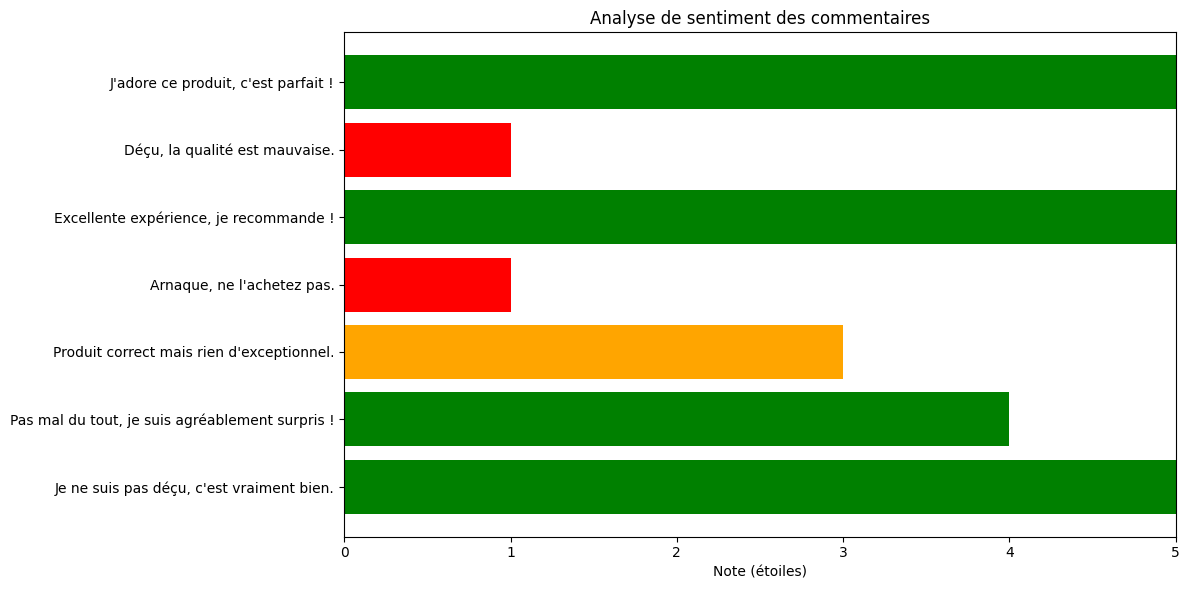

In [9]:
import matplotlib.pyplot as plt

# Analyser tous les commentaires
resultats = [analyseur(c)[0] for c in commentaires_test]
notes = [int(r["label"].split()[0]) for r in resultats]

# Créer le graphique
plt.figure(figsize=(12, 6))
couleurs = ["red" if n <= 2 else "orange" if n == 3 else "green" for n in notes]
plt.barh(range(len(commentaires_test)), notes, color=couleurs)
plt.yticks(range(len(commentaires_test)), [c[:50] + "..." if len(c) > 50 else c for c in commentaires_test])
plt.xlabel("Note (étoiles)")
plt.title("Analyse de sentiment des commentaires")
plt.xlim(0, 5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()